<a href="https://colab.research.google.com/github/ElvinaShukurova/Telecom/blob/main/Lab10_Shukurova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

--2026-05-05 13:29:38--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-05 13:29:39--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.007s  

2026-05-05 13:29:39 (6.76 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



In [2]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

# Упражнение 10.1

In [3]:
if not os.path.exists('180960__kleeb__gunshot.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/180960__kleeb__gunshot.wav

--2026-05-05 13:29:53--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/180960__kleeb__gunshot.wav
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/180960__kleeb__gunshot.wav [following]
--2026-05-05 13:29:53--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/180960__kleeb__gunshot.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 379256 (370K) [audio/wav]
Saving to: ‘180960__kleeb__gunshot.wav’

180960__kleeb__guns 100%[===================>] 370.37K  --.-KB/s    in 0.03s   

2026-05-05 13:29:53 (13.9 MB/s) - ‘180960__kleeb__gunshot.w

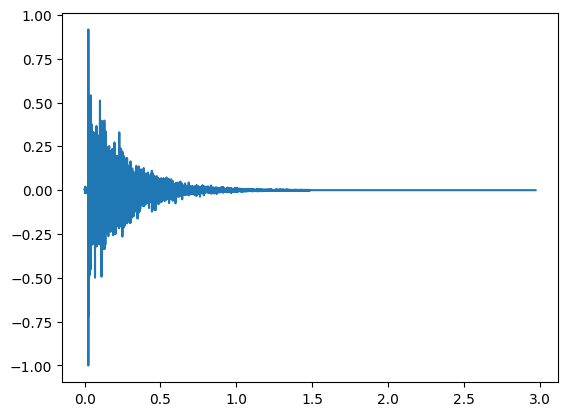

In [4]:
from thinkdsp import read_wave

response = read_wave('180960__kleeb__gunshot.wav')

start = 0.12
response = response.segment(start=start)
response.shift(-start)

response.truncate(2**16)
response.zero_pad(2**17)

response.normalize()
response.plot()

In [5]:
response.make_audio()

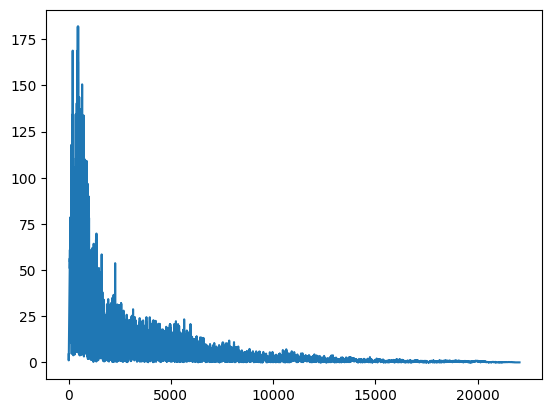

In [6]:
transfer = response.make_spectrum()
transfer.plot()

In [7]:
if not os.path.exists('92002__jcveliz__violin-origional.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/92002__jcveliz__violin-origional.wav

--2026-05-05 13:34:53--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/92002__jcveliz__violin-origional.wav
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/92002__jcveliz__violin-origional.wav [following]
--2026-05-05 13:34:54--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/92002__jcveliz__violin-origional.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 441044 (431K) [audio/wav]
Saving to: ‘92002__jcveliz__violin-origional.wav’

92002__jcveliz__vio 100%[===================>] 430.71K  --.-KB/s    in 0.02s   

2026-05-05 13:34:54

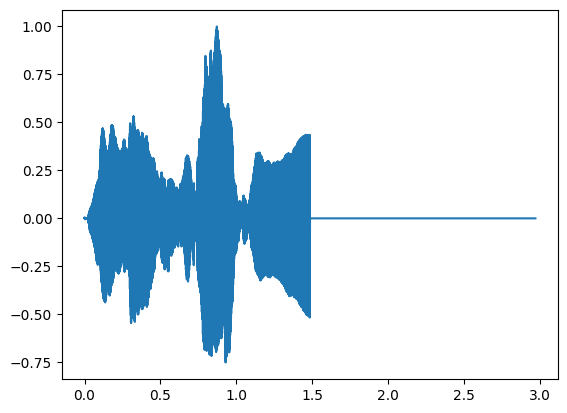

In [8]:
violin = read_wave('92002__jcveliz__violin-origional.wav')

start = 0.11
violin = violin.segment(start=start)
violin.shift(-start)

violin.truncate(2**16)
violin.zero_pad(2**17)

violin.normalize()
violin.plot()

In [9]:
violin.make_audio()

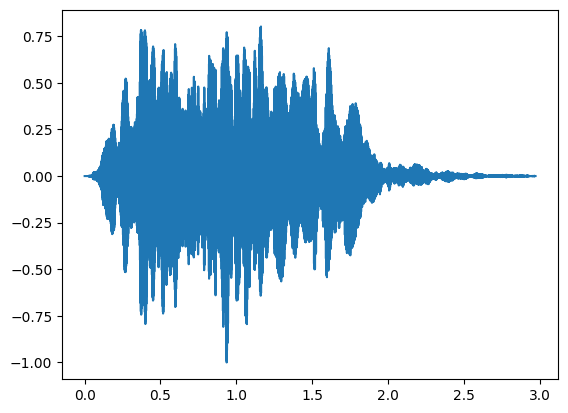

In [10]:
violin_short = violin.copy()
violin_short.truncate(len(response))
transfer = response.make_spectrum()
spectrum = violin_short.make_spectrum()
output = (spectrum * transfer).make_wave()
output.normalize()
output.plot()

In [11]:
output.make_audio()

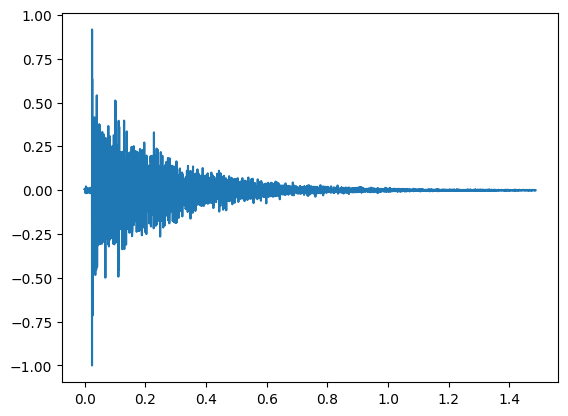

In [12]:
response.truncate(2**16)
response.plot()

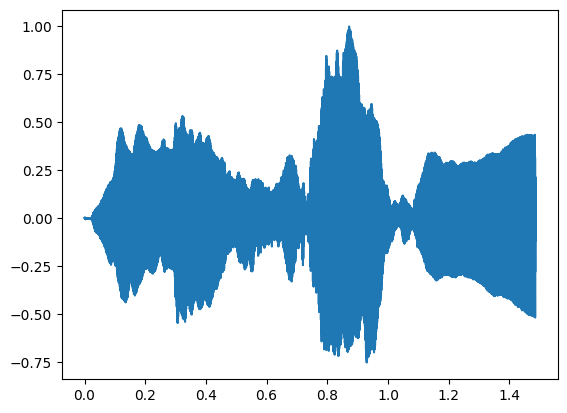

In [13]:
violin.truncate(2**16)
violin.plot()

In [14]:
output2 = violin.convolve(response)

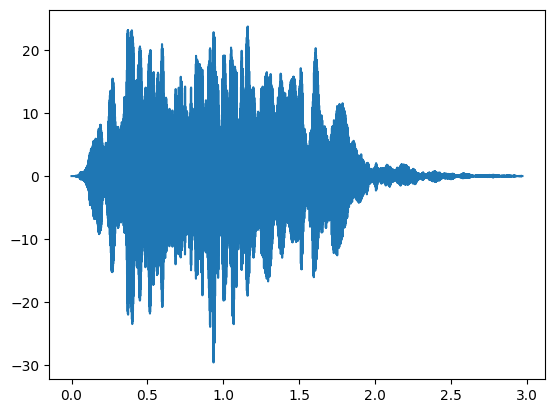

In [15]:
output2.plot()

In [16]:
output2.make_audio()

In [17]:
len(output), len(output2)

(131072, 131071)

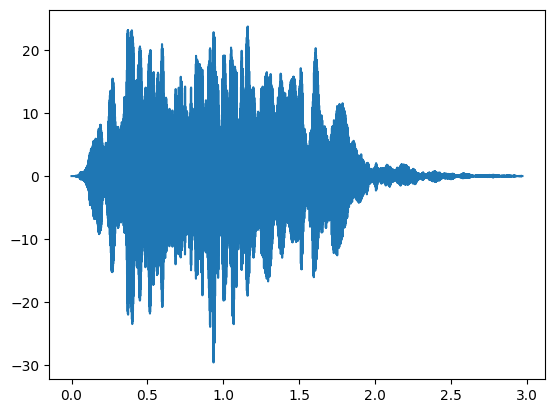

In [19]:
from thinkdsp import Wave

import scipy.signal
ys = scipy.signal.fftconvolve(violin.ys, response.ys)
output3 = Wave(ys, framerate=violin.framerate)
output3.plot()

In [20]:
output3.make_audio()

In [21]:
output2.max_diff(output3)

np.float64(2.1316282072803006e-14)

# Упражнение 10.2

In [22]:
if not os.path.exists('stalbans_a_mono.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/stalbans_a_mono.wav

--2026-05-05 13:44:57--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/stalbans_a_mono.wav
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/stalbans_a_mono.wav [following]
--2026-05-05 13:44:57--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/stalbans_a_mono.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793906 (775K) [audio/wav]
Saving to: ‘stalbans_a_mono.wav’

stalbans_a_mono.wav 100%[===================>] 775.30K  --.-KB/s    in 0.03s   

2026-05-05 13:44:57 (28.2 MB/s) - ‘stalbans_a_mono.wav’ saved [793906/793906]



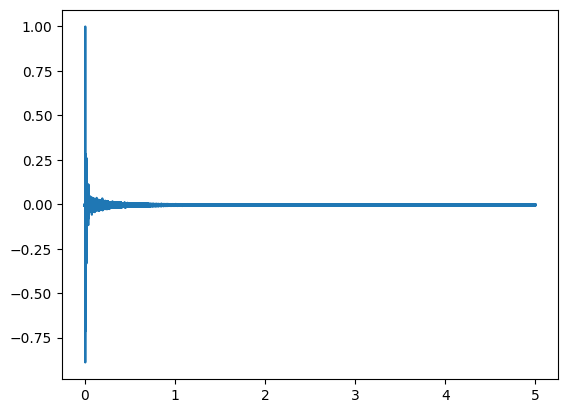

In [23]:
response = read_wave('stalbans_a_mono.wav')
start = 0
duration = 5
response = response.segment(duration=duration)
response.shift(-start)
response.normalize()
response.plot()

In [24]:
response.make_audio()

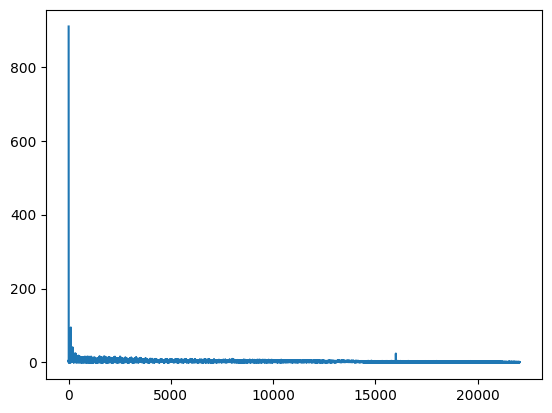

In [25]:
transfer = response.make_spectrum()
transfer.plot()

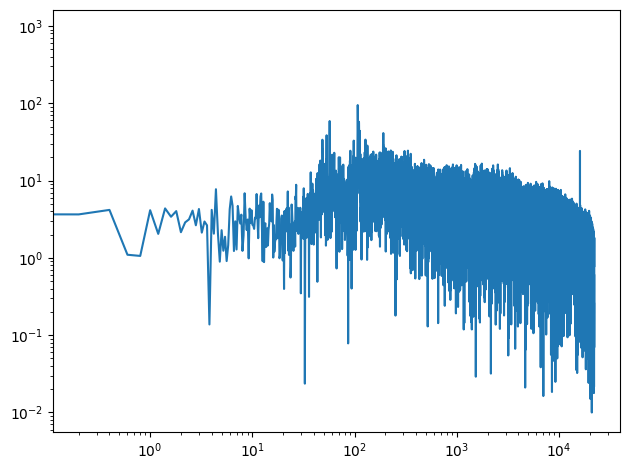

In [26]:
transfer.plot()
decorate(xscale='log', yscale='log')

In [27]:
if not os.path.exists('170255__dublie__trumpet.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/170255__dublie__trumpet.wav

--2026-05-05 13:46:19--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/170255__dublie__trumpet.wav
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/170255__dublie__trumpet.wav [following]
--2026-05-05 13:46:20--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/170255__dublie__trumpet.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1540668 (1.5M) [audio/wav]
Saving to: ‘170255__dublie__trumpet.wav’

170255__dublie__tru 100%[===================>]   1.47M  --.-KB/s    in 0.03s   

2026-05-05 13:46:20 (45.9 MB/s) - ‘170255__dublie__tru

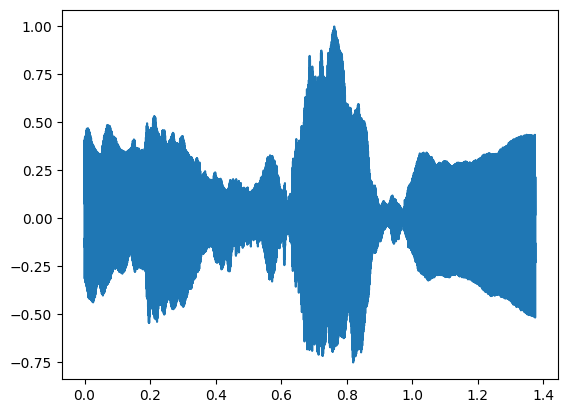

In [30]:
wave = read_wave('170255__dublie__trumpet.wav')

start = 0.11
violin = violin.segment(start=start)
violin.shift(-start)
violin.normalize()
violin.plot()

In [31]:
N = len(violin) + len(response)
violin_padded = violin.copy()
violin_padded.zero_pad(N)
response_padded = response.copy()
response_padded.zero_pad(N)
violin_spectrum = violin_padded.make_spectrum()
response_spectrum = response_padded.make_spectrum()
output = (violin_spectrum * response_spectrum).make_wave()
output.normalize()
output.make_audio()

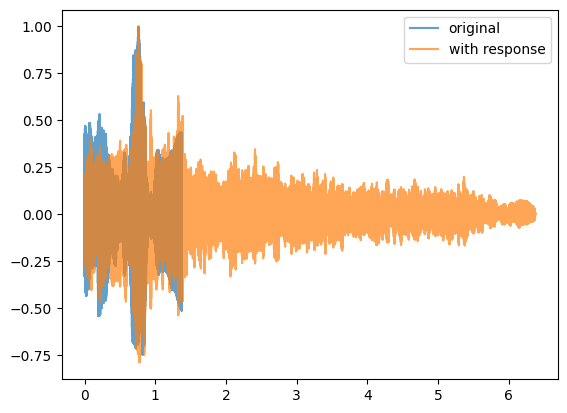

In [32]:
violin.plot(label='original', alpha=0.7)
output.plot(label='with response', alpha=0.7)
plt.legend()

В работе использовалась импульсная характеристика помещения, полученная из записи короткого звукового сигнала. При её применении к звуку скрипки сформировался новый сигнал с выраженным затухающим «хвостом». Длительность сигнала увеличилась, а его форма изменилась в соответствии со свойствами среды. Это показывает, что свёртка с импульсной характеристикой позволяет моделировать распространение звука в акустическом пространстве.